# Where ERCOT's EWS documentation and its schemas disagree

**Unofficial.** Not affiliated with or endorsed by ERCOT.

ERCOT describes its External Web Services (EWS) twice: in XML schemas (XSDs) that a program
can validate against, and on its developer portal, in requirement tables, structure diagrams and
XML examples that a person reads. This notebook recomputes, from the files vendored in
ercot-ews-check, how often and where the two descriptions disagree in ways that can be shown
from ERCOT's own files.

Every figure below is computed here. Nothing is fetched: the checker carries copies of ERCOT's
schemas (from [ercot/api-specs](https://github.com/ercot/api-specs)) and of the portal's text,
and the catalogue entries in `discrepancies/` record each disagreement with probes that re-check
ERCOT's side and the schema's side.

To run it: `python -m pip install "ercot-ews-check @ git+https://github.com/wattness/ercot-ews-check@v0.2.0" jupyter`,
then open this notebook.

In [1]:
import json
import os
from collections import Counter
from pathlib import Path

from IPython.display import SVG, display

import ercot_ews_check
from ercot_ews_check import checker, discrepancies, examples, requirements, sources

print(f"ercot-ews-check {ercot_ews_check.__version__}")
print(
    f"ERCOT's schemas: ercot/api-specs {sources.api_specs_commit()[:7]}, "
    f"retrieved {sources.manifest()['files'][0]['retrieved']}"
)

ercot-ews-check 0.2.0
ERCOT's schemas: ercot/api-specs 7e785be, retrieved 2026-10-07


## The catalogue

Each entry names the ERCOT page that says one thing and the schema line that says another, with
a resolution: follow the schema, follow the documentation (the schema accepts what ERCOT's stated
rule does not), neither settles it, or the page describes something ERCOT has removed.

Where ERCOT's side of each entry sits is read from the entry itself: a structure diagram, an XML
example (on a portal page, in an appendix's annotated message, or in api-specs' `ews/examples`),
a requirement table, or other prose.

In [2]:
def where(entry):
    location = (entry.ercot_says.get("location") or "").lower()
    if location.startswith("diagram") or "structure diagram" in location:
        return "Structure diagrams"
    if "example" in location or "envelope" in location or "file" in entry.probes:
        return "XML examples"
    if "table" in location:
        return "Requirement tables"
    return "Other prose"


LABELS = {
    "schema-wins": "Follow the schema",
    "prose-wins": "Follow the documentation",
    "neither": "Neither settles it",
    "prose-stale": "Describes something removed",
}

entries = discrepancies.entries()
by_where = Counter(where(e) for e in entries)
by_resolution = Counter(e.resolution for e in entries)
grid = Counter((where(e), e.resolution) for e in entries)

print(f"{len(entries)} entries")
for name, n in by_where.most_common():
    print(f"  {name}: {n}")
for name, n in by_resolution.most_common():
    print(f"  {LABELS[name]}: {n}")

47 entries
  Requirement tables: 15
  Structure diagrams: 12
  XML examples: 11
  Other prose: 9
  Follow the schema: 36
  Neither settles it: 6
  Follow the documentation: 3
  Describes something removed: 2


In [3]:
probes = discrepancies.verify()
print(f"{sum(p.ok for p in probes)} of {len(probes)} probes still match the vendored files")

95 of 95 probes still match the vendored files


## Documents that show it

For most entries the catalogue carries a pair of documents: one that ERCOT's documentation and
its schema treat differently, and a corrected one. The checker runs on both.

In [4]:
pairs = [e for e in entries if e.reproducer]
first = {e.id: checker.check(e.reproducer["invalid"]) for e in pairs}
by_schema = sorted(i for i, r in first.items() if r.schema != "valid")
by_rule = sorted(i for i, r in first.items() if r.schema == "valid" and r.blocked)
corrected = [e for e in pairs if "valid" in e.reproducer]
clean = [e for e in corrected if checker.check(e.reproducer["valid"]).findings == []]

print(f"{len(pairs)} entries carry documents")
print(f"  blocked: {sum(r.blocked for r in first.values())} of {len(pairs)}")
print(f"  rejected by ERCOT's own XSDs: {len(by_schema)}")
print(f"  valid against the XSDs, blocked by a rule ERCOT states: {len(by_rule)} {by_rule}")
print(f"  corrected documents with no finding: {len(clean)} of {len(corrected)}")

39 entries carry documents
  blocked: 39 of 39
  rejected by ERCOT's own XSDs: 35
  valid against the XSDs, blocked by a rule ERCOT states: 4 ['D005', 'D006', 'D007', 'D046']
  corrected documents with no finding: 37 of 37


## ERCOT's own samples

The portal's XML samples, run through the same schemas. Fragments and abbreviated samples are
counted, not checked.

In [5]:
samples = examples.counts()
api_specs = examples.api_specs_examples()
tables = requirements.tables()
print(
    f"{samples['samples']} distinct XML blocks on EWS pages; {samples['complete']} complete "
    f"documents, of which {samples['invalid']} fail ERCOT's own XSDs"
)
print(
    f"api-specs ews/examples: {sum(not v.ok for v in api_specs.values())} of {len(api_specs)} "
    "fail ERCOT's own XSDs"
)
print(
    f"Requirement tables: {sum(len(t) for t in tables.values())} element rows on "
    f"{len(tables)} portal pages"
)

178 distinct XML blocks on EWS pages; 98 complete documents, of which 14 fail ERCOT's own XSDs
api-specs ews/examples: 2 of 3 fail ERCOT's own XSDs
Requirement tables: 487 element rows on 29 portal pages


## The chart

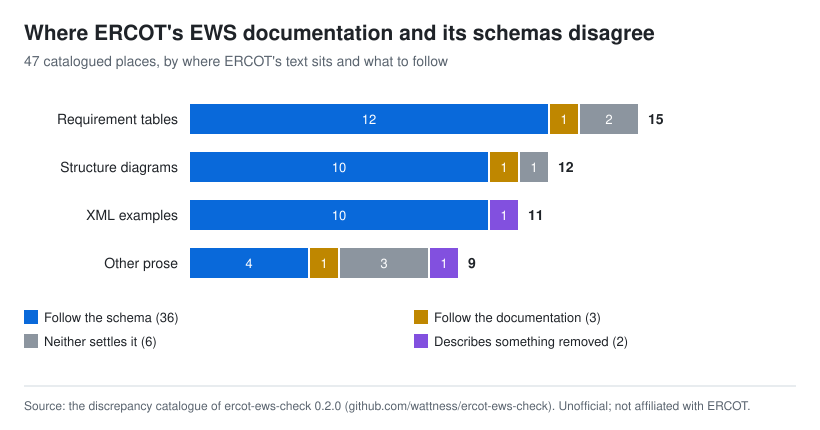

In [6]:
ROWS = ["Requirement tables", "Structure diagrams", "XML examples", "Other prose"]
SEGMENTS = list(LABELS.items())
THEMES = {
    "light": {
        "bg": "#ffffff",
        "ink": "#1f2328",
        "muted": "#59636e",
        "rule": "#d1d9e0",
        "schema-wins": "#0969da",
        "prose-wins": "#bf8700",
        "neither": "#8c959f",
        "prose-stale": "#8250df",
        "on": "#ffffff",
    },
    "dark": {
        "bg": "#0d1117",
        "ink": "#e6edf3",
        "muted": "#9198a1",
        "rule": "#3d444d",
        "schema-wins": "#4493f8",
        "prose-wins": "#d29922",
        "neither": "#6e7681",
        "prose-stale": "#ab7df8",
        "on": "#0d1117",
    },
}
FONT = "system-ui, -apple-system, 'Segoe UI', Helvetica, Arial, sans-serif"


def chart(theme: str) -> str:
    t = THEMES[theme]
    width, left, unit, bar, gap, top = 820, 190, 30, 30, 18, 104
    rows_h = len(ROWS) * (bar + gap)
    height = top + rows_h + 134
    out = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" '
        f'viewBox="0 0 {width} {height}" font-family="{FONT}">',
        f'<rect width="{width}" height="{height}" fill="{t["bg"]}"/>',
        f'<text x="24" y="40" font-size="21" font-weight="600" fill="{t["ink"]}">'
        f"Where ERCOT's EWS documentation and its schemas disagree</text>",
        f'<text x="24" y="66" font-size="14" fill="{t["muted"]}">'
        f"{len(entries)} catalogued places, by where ERCOT's text sits and what to follow</text>",
    ]
    for i, row in enumerate(ROWS):
        y = top + i * (bar + gap)
        out.append(
            f'<text x="{left - 12}" y="{y + bar / 2 + 5}" font-size="14" '
            f'text-anchor="end" fill="{t["ink"]}">{row}</text>'
        )
        x = left
        for key, _ in SEGMENTS:
            n = grid[(row, key)]
            if not n:
                continue
            w = n * unit
            out.append(f'<rect x="{x}" y="{y}" width="{w - 2}" height="{bar}" fill="{t[key]}"/>')
            out.append(
                f'<text x="{x + (w - 2) / 2}" y="{y + bar / 2 + 5}" font-size="13" '
                f'text-anchor="middle" fill="{t["on"]}">{n}</text>'
            )
            x += w
        out.append(
            f'<text x="{x + 8}" y="{y + bar / 2 + 5}" font-size="14" font-weight="600" '
            f'fill="{t["ink"]}">{by_where[row]}</text>'
        )
    for k, (key, label) in enumerate(SEGMENTS):
        x, y = 24 + (k % 2) * 390, top + rows_h + 14 + (k // 2) * 24
        out.append(f'<rect x="{x}" y="{y}" width="14" height="14" fill="{t[key]}"/>')
        out.append(
            f'<text x="{x + 20}" y="{y + 12}" font-size="13" fill="{t["ink"]}">'
            f"{label} ({by_resolution[key]})</text>"
        )
    out.append(
        f'<line x1="24" y1="{height - 44}" x2="{width - 24}" y2="{height - 44}" '
        f'stroke="{t["rule"]}"/>'
    )
    source = (
        f"Source: the discrepancy catalogue of ercot-ews-check {ercot_ews_check.__version__} "
        "(github.com/wattness/ercot-ews-check). Unofficial; not affiliated with ERCOT."
    )
    out.append(f'<text x="24" y="{height - 20}" font-size="12" fill="{t["muted"]}">{source}</text>')
    out.append("</svg>")
    return "\n".join(out)


display(SVG(chart("light")))

To save the chart (light and dark SVG) and these figures as JSON, set `FIELD_NOTE_OUT` to
a folder before starting Jupyter.

In [ ]:
out = os.environ.get("FIELD_NOTE_OUT")
if out:
    folder = Path(out)
    for theme in THEMES:
        (folder / f"chart-{theme}.svg").write_text(chart(theme), encoding="utf-8")
    figures = {
        "version": ercot_ews_check.__version__,
        "entries": len(entries),
        "by_where": dict(by_where),
        "by_resolution": dict(by_resolution),
        "probes": [sum(p.ok for p in probes), len(probes)],
        "pairs": len(pairs),
        "blocked": sum(r.blocked for r in first.values()),
        "rejected_by_xsd": len(by_schema),
        "blocked_by_stated_rule": by_rule,
        "corrected_clean": [len(clean), len(corrected)],
        "samples": samples,
        "api_specs_failing": [sum(not v.ok for v in api_specs.values()), len(api_specs)],
        "table_rows": [sum(len(t) for t in tables.values()), len(tables)],
    }
    (folder / "figures.json").write_text(json.dumps(figures, indent=1), encoding="utf-8")
    print(f"wrote the chart and figures.json to {folder.name}/")